In [1]:
import pprint
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision.transforms import transforms
from torch.utils.data import DataLoader
from matplotlib import pyplot as plt
import pandas as pd
import torch.optim as optim
from tqdm import tqdm
from torchinfo import summary
import numpy as np

from variables import *
from model import EmotionClassifier
from get_dataset import GiMeFiveDataset

from os import mkdir, path

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

print(f"Using device: {device}")
print(f"Running {experiment_name} experiment")
pprint.pp(configuration)

Using device: mps
Running class_weights_ADAMW_1 experiment
{'apply_class_weight': True,
 'optimizer': 'adam_optimizer',
 'dataset': 'GiMeFive',
 'hyperparameters': {'num_epochs': 80,
                     'batch_size': 16,
                     'learning_rate': 0.001,
                     'weight_decay': 0.0001,
                     'dropout1': 0.3,
                     'conv5_filters': 768}}


In [6]:
transform = transforms.Compose(
    [
        transforms.Resize((64, 64)),
        transforms.Grayscale(num_output_channels=3),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ]
)

train_dataset = GiMeFiveDataset(
    csv_file=dataset["train"]["labels"],
    img_dir=dataset["train"]["images"],
    transform=transform,
)
train_data_loader = DataLoader(
    train_dataset, batch_size=hyperparameters["batch_size"], shuffle=True, num_workers=4
)
train_image, train_label = next(iter(train_data_loader))
print(f"Train batch: image shape {train_image.shape}, labels shape {train_label.shape}")

validation_dataset = GiMeFiveDataset(
    csv_file=dataset["validation"]["labels"],
    img_dir=dataset["validation"]["images"],
    transform=transform,
)
validation_data_loader = DataLoader(
    validation_dataset,
    batch_size=hyperparameters["batch_size"],
    shuffle=False,
    num_workers=0,
)
validation_image, validation_label = next(iter(validation_data_loader))
print(
    f"Validation batch: image shape {validation_image.shape}, labels shape {validation_label.shape}"
)

test_dataset = GiMeFiveDataset(
    csv_file=dataset["test"]["labels"],
    img_dir=dataset["test"]["images"],
    transform=transform,
)

test_data_loader = DataLoader(
    test_dataset, batch_size=hyperparameters["batch_size"], shuffle=False, num_workers=0
)

test_image, test_label = next(iter(test_data_loader))
print(f"Test batch: image shape {test_image.shape}, labels shape {test_label.shape}")

Train batch: image shape torch.Size([16, 3, 64, 64]), labels shape torch.Size([16])
Validation batch: image shape torch.Size([16, 3, 64, 64]), labels shape torch.Size([16])
Test batch: image shape torch.Size([16, 3, 64, 64]), labels shape torch.Size([16])


In [ ]:
model = EmotionClassifier().to(device)

print(summary(model, input_size=(hyperparameters["batch_size"], 3, 64, 64)))

Layer (type:depth-idx)                   Output Shape              Param #
EmotionClassifier                        [16, 6]                   --
├─Conv2d: 1-1                            [16, 64, 64, 64]          1,792
├─BatchNorm2d: 1-2                       [16, 64, 64, 64]          128
├─Dropout: 1-3                           [16, 64, 32, 32]          --
├─Conv2d: 1-4                            [16, 128, 32, 32]         73,856
├─BatchNorm2d: 1-5                       [16, 128, 32, 32]         256
├─Dropout: 1-6                           [16, 128, 16, 16]         --
├─Conv2d: 1-7                            [16, 256, 16, 16]         295,168
├─BatchNorm2d: 1-8                       [16, 256, 16, 16]         512
├─Dropout: 1-9                           [16, 256, 8, 8]           --
├─Conv2d: 1-10                           [16, 512, 8, 8]           1,180,160
├─BatchNorm2d: 1-11                      [16, 512, 8, 8]           1,024
├─Dropout: 1-12                          [16, 512, 4, 4]    

In [8]:
# Input weight balancing.

if configuration["apply_class_weight"]:

    def get_class_weights(dataset):
        total_samples = len(dataset)
        unique_labels = np.unique([label for _, label in dataset], return_counts=True)[
            1
        ]

        class_weights = [(total_samples / count) for count in unique_labels]
        return class_weights

    class_weights = torch.Tensor(get_class_weights(train_dataset)).to(device)
    print("Using CrossEntropyLoss with class weights:", class_weights)
    criterion = nn.CrossEntropyLoss(weight=class_weights)
else:
    print("Using CrossEntropyLoss without class weights")
    criterion = nn.CrossEntropyLoss()

Using CrossEntropyLoss with class weights: tensor([ 3.2134,  6.3895,  5.5237,  6.8873, 14.7683,  7.2281], device='mps:0')


In [9]:
print("Using", configuration["optimizer"])

match configuration["optimizer"]:
    case "adam_optimizer":
        optimizer = optim.Adam(
            model.parameters(),
            lr=hyperparameters["learning_rate"],
            weight_decay=hyperparameters["weight_decay"],
        )
    case "adamw_optimizer":
        optimizer = optim.AdamW(
            model.parameters(),
            lr=hyperparameters["learning_rate"],
            weight_decay=hyperparameters["weight_decay"],
        )
    case "sgd_optimizer":
        optimizer = optim.SGD(
            model.parameters(),
            lr=hyperparameters["learning_rate"],
            momentum=hyperparameters["momentum"],
            weight_decay=hyperparameters["weight_decay"],
        )

best_val_acc = 0

num_epochs = hyperparameters["num_epochs"]

model_filename = f"{output_path}/{experiment_name}/model.pth"
if not path.exists(f"{output_path}/{experiment_name}"):
    mkdir(f"{output_path}/{experiment_name}")

Using adam_optimizer


In [10]:
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []
test_losses = []
test_accuracies = []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for data in tqdm(train_data_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):
        inputs, labels = data[0].to(device), data[1].to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_data_loader)
    train_acc = correct / total
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)

    model.eval()
    test_running_loss = 0.0
    test_correct = 0
    test_total = 0
    with torch.no_grad():
        for data in test_data_loader:
            inputs, labels = data[0].to(device), data[1].to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            test_running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            test_total += labels.size(0)
            test_correct += (predicted == labels).sum().item()

    test_loss = test_running_loss / len(test_data_loader)
    test_acc = test_correct / test_total
    test_losses.append(test_loss)
    test_accuracies.append(test_acc)

    model.eval()
    val_running_loss = 0.0
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for data in validation_data_loader:
            inputs, labels = data[0].to(device), data[1].to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_loss = val_running_loss / len(validation_data_loader)
    val_acc = val_correct / val_total
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    print(
        f"Epoch {epoch+1}, Train Loss: {train_loss}, Train Accuracy: {train_acc}, Test Loss: {test_loss}, Test Accuracy: {test_acc}, Validation Loss: {val_loss}, Validation Accuracy: {val_acc}"
    )

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), model_filename)

Epoch 1/80: 100%|██████████| 3442/3442 [01:38<00:00, 34.88it/s]


Epoch 1, Train Loss: 1.6908421082457854, Train Accuracy: 0.3402516751103121, Test Loss: 1.5236371481029636, Test Accuracy: 0.4632741238598176, Validation Loss: 1.7316846502454657, Validation Accuracy: 0.31886477462437396


Epoch 2/80: 100%|██████████| 3442/3442 [01:38<00:00, 34.78it/s]


Epoch 2, Train Loss: 1.4819337177906946, Train Accuracy: 0.4403951262915146, Test Loss: 1.2632398881919096, Test Accuracy: 0.5219635141622659, Validation Loss: 1.6224267451386702, Validation Accuracy: 0.3789649415692821


Epoch 3/80: 100%|██████████| 3442/3442 [01:38<00:00, 34.90it/s]


...

Epoch 78, Train Loss: 0.23681557716896193, Train Accuracy: 0.9220097692070237, Test Loss: 0.9103195099839351, Test Accuracy: 0.7178348535765723, Validation Loss: 1.2065994849330501, Validation Accuracy: 0.7011686143572621


Epoch 79/80: 100%|██████████| 3442/3442 [01:37<00:00, 35.23it/s]


Epoch 79, Train Loss: 0.24857076900599354, Train Accuracy: 0.9196673385266293, Test Loss: 0.9544667356259648, Test Accuracy: 0.7127940470475276, Validation Loss: 1.2119047422158091, Validation Accuracy: 0.7061769616026711


Epoch 80/80: 100%|██████████| 3442/3442 [01:37<00:00, 35.21it/s]


Epoch 80, Train Loss: 0.2314777738782147, Train Accuracy: 0.9248606344537053, Test Loss: 0.9772856631816763, Test Accuracy: 0.7179548727796448, Validation Loss: 1.403430479137521, Validation Accuracy: 0.6944908180300501


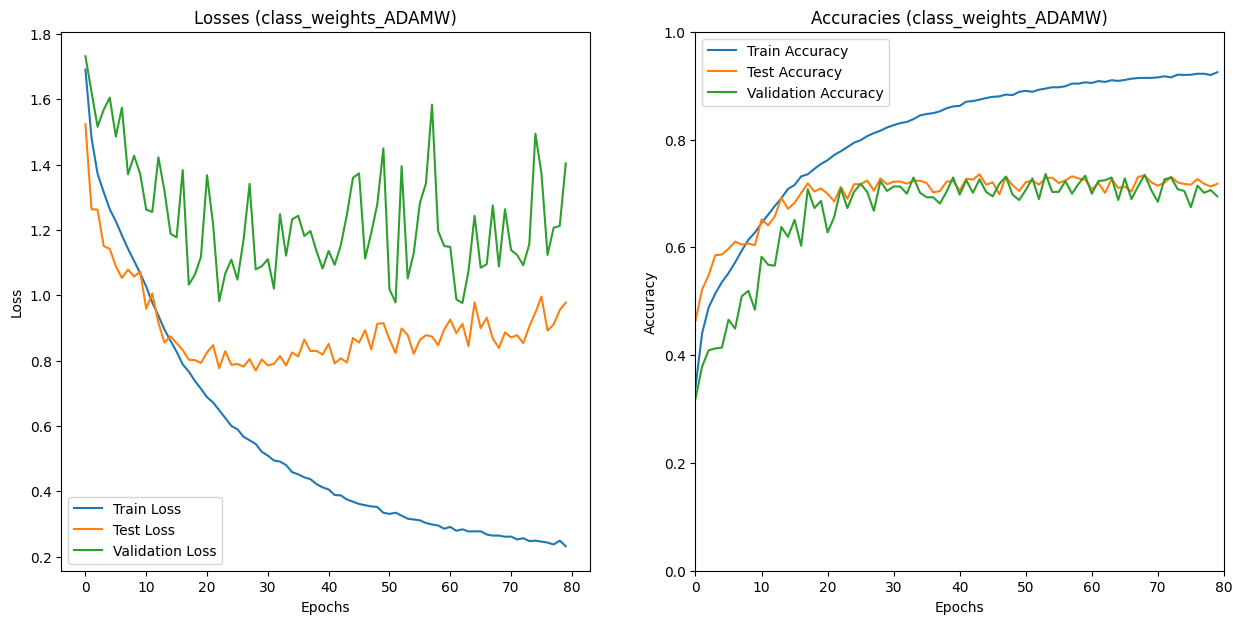

In [11]:
file_name = f"{output_path}/{experiment_name}/learning_curve.png"

plt.figure(figsize=(15, 7))
plt.subplot(1, 2, 1)
plt.plot(range(num_epochs), train_losses, label="Train Loss")
plt.plot(range(num_epochs), test_losses, label="Test Loss")
plt.plot(range(num_epochs), val_losses, label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title(f"Losses ({experiment_name})")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(range(num_epochs), train_accuracies, label="Train Accuracy")
plt.plot(range(num_epochs), test_accuracies, label="Test Accuracy")
plt.plot(range(num_epochs), val_accuracies, label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title(f"Accuracies ({experiment_name})")
plt.legend()

ax = plt.gca()
ax.set_xlim([0, num_epochs])
ax.set_ylim([0, 1])

plt.savefig(file_name, dpi=400, bbox_inches="tight", pad_inches=0.1)
plt.show()

In [12]:
df = pd.DataFrame(
    {
        "Epoch": range(
            1, num_epochs + 1
        ),  # change this number after '(1, _)' to num_epochs+1
        "Train Loss": train_losses,
        "Test Loss": test_losses,
        "Validation Loss": val_losses,
        "Train Accuracy": train_accuracies,
        "Test Accuracy": test_accuracies,
        "Validation Accuracy": val_accuracies,
    }
)
df.to_csv(
    f"{output_path}/{experiment_name}/result.csv",
    index=False,
)